In [66]:
import tensorflow as tf
import pathlib
import random
import tqdm
import matplotlib.pyplot as plt
%matplotlib inline

In [8]:
print(tf.__version__)


2.19.0


In [11]:
import psutil
import platform

print("--- CPU Information ---")
print(f"Processor: {platform.processor()}")
print(f"Physical cores: {psutil.cpu_count(logical=False)}")
print(f"Total cores: {psutil.cpu_count(logical=True)}")
print(f"CPU frequency: {psutil.cpu_freq().current:.2f} Mhz")
print(f"Total RAM: {round(psutil.virtual_memory().total / (1024**3), 2)} GB")

--- CPU Information ---
Processor: x86_64
Physical cores: 1
Total cores: 2
CPU frequency: 2200.00 Mhz
Total RAM: 12.67 GB


In [3]:
print("\n--- GPU Information ---")
try:
    !nvidia-smi
except:
    print("No NVIDIA GPU found or nvidia-smi not available.")
    print("Attempting to get general display info:")
    !lshw -C display


--- GPU Information ---
/bin/bash: line 1: nvidia-smi: command not found


In [24]:
import pathlib
import tensorflow as tf

file_http = 'https://storage.googleapis.com/download.tensorflow.org/example_images/flower_photos.tgz'
file_name = 'flower_photos'
data_root = tf.keras.utils.get_file(origin=file_http, fname=file_name, untar=True)
data_root = pathlib.Path(data_root) # convert string to path
print(data_root)

/root/.keras/datasets/flower_photos


In [25]:
# show alll files in the data folder
print(type(data_root))
print([item.name for item in data_root.iterdir()])
data_root = data_root/'flower_photos'
class_names = [item.name for item in data_root.iterdir() if item.is_dir()]
print(class_names)
# convert the flower name to integer
class_id_from_name = {name:i for i , name in enumerate(class_names)}
print(class_id_from_name)

<class 'pathlib.PosixPath'>
['flower_photos']
['sunflowers', 'tulips', 'roses', 'daisy', 'dandelion']
{'sunflowers': 0, 'tulips': 1, 'roses': 2, 'daisy': 3, 'dandelion': 4}


In [26]:
# get all subdir files name
all_images_paths = list(data_root.glob('*/*'))
print(len(all_images_paths))
print(all_images_paths[:5])

3670
[PosixPath('/root/.keras/datasets/flower_photos/flower_photos/sunflowers/7721658400_0dec46d225.jpg'), PosixPath('/root/.keras/datasets/flower_photos/flower_photos/sunflowers/5896354497_6a19162741.jpg'), PosixPath('/root/.keras/datasets/flower_photos/flower_photos/sunflowers/8249000137_eddfffa380_n.jpg'), PosixPath('/root/.keras/datasets/flower_photos/flower_photos/sunflowers/1485456230_58d8e45e88.jpg'), PosixPath('/root/.keras/datasets/flower_photos/flower_photos/sunflowers/164668737_aeab0cb55e_n.jpg')]


In [28]:
random.shuffle(all_images_paths)
print(all_images_paths[:5])

[PosixPath('/root/.keras/datasets/flower_photos/flower_photos/tulips/13513644515_a51470b899.jpg'), PosixPath('/root/.keras/datasets/flower_photos/flower_photos/roses/3742155164_14b557a51c_n.jpg'), PosixPath('/root/.keras/datasets/flower_photos/flower_photos/tulips/480228053_513791d474.jpg'), PosixPath('/root/.keras/datasets/flower_photos/flower_photos/roses/505517255_cfbb6f6394.jpg'), PosixPath('/root/.keras/datasets/flower_photos/flower_photos/roses/160954292_6c2b4fda65_n.jpg')]


In [29]:
all_images_with_class = [(item.parent.name, item.name) for item in all_images_paths]
print(all_images_with_class[:5])

[('tulips', '13513644515_a51470b899.jpg'), ('roses', '3742155164_14b557a51c_n.jpg'), ('tulips', '480228053_513791d474.jpg'), ('roses', '505517255_cfbb6f6394.jpg'), ('roses', '160954292_6c2b4fda65_n.jpg')]


In [30]:
print(type(all_images_paths))

<class 'list'>


In [31]:
a1 = all_images_paths[0]
print(a1)

/root/.keras/datasets/flower_photos/flower_photos/tulips/13513644515_a51470b899.jpg


In [33]:
print(a1.parent)
print(type(a1))

/root/.keras/datasets/flower_photos/flower_photos/tulips
<class 'pathlib.PosixPath'>


In [36]:
# convert dataset to TFRecord file
# class_name,  image_name, class_id, height, width, img_raw(image binary object), img_resized(image matrix)
class_name, image_name = all_images_with_class[0]
class_id = class_id_from_name[class_name]
resize_to = 192
img_fname = data_root/class_name/image_name
assert img_fname.exists()
# img_raw = tf.io.read_file(str(img_fname))
with tf.io.gfile.GFile(str(img_fname), 'rb') as f:
  img_raw = f.read()
img_matrix = tf.image.decode_jpeg(img_raw,  channels=3)
print(type(img_raw))
print(img_raw)
height, width, channel= img_matrix.shape
img_resized  = tf.image.resize(img_matrix, [resize_to, resize_to])

<class 'bytes'>
b'\xff\xd8\xff\xe0\x00\x10JFIF\x00\x01\x01\x01\x00H\x00H\x00\x00\xff\xe2\x0cXICC_PROFILE\x00\x01\x01\x00\x00\x0cHLino\x02\x10\x00\x00mntrRGB XYZ \x07\xce\x00\x02\x00\t\x00\x06\x001\x00\x00acspMSFT\x00\x00\x00\x00IEC sRGB\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\xf6\xd6\x00\x01\x00\x00\x00\x00\xd3-HP  \x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x11cprt\x00\x00\x01P\x00\x00\x003desc\x00\x00\x01\x84\x00\x00\x00lwtpt\x00\x00\x01\xf0\x00\x00\x00\x14bkpt\x00\x00\x02\x04\x00\x00\x00\x14rXYZ\x00\x00\x02\x18\x00\x00\x00\x14gXYZ\x00\x00\x02,\x00\x00\x00\x14bXYZ\x00\x00\x02@\x00\x00\x00\x14dmnd\x00\x00\x02T\x00\x00\x00pdmdd\x00\x00\x02\xc4\x00\x00\x00\x88vued\x00\x00\x03L\x00\x00\x00\x86view\x00\x00\x03\xd4\x00\x00\x00$lumi\x00\x00\x03\xf8\x00\x00\x00\x14meas\x00\x00\x04\x0c\x00\x00\x00$tech\x00\x00\x040\x00\x00\x00\x0crTRC

In [38]:
# TFRecord datatype BytesList, FloatList, Int64List
d0 = tf.train.BytesList(value=["hhellll".encode('utf-8')])
d1 = tf.train.Int64List(value=[1, 2])
d2 = tf.train.FloatList(value=[3.13, 2.44])
print(d0, d1, d2)

value: "hhellll"
 value: 1
value: 2
 value: 3.13
value: 2.44



In [59]:
from numpy import int64
# convert matrix to binary then use TFRecord datatype to handle
def convert_build(data_root, class_name, img_name, class_id, resize_to=192):
  img_fname = data_root/class_name/img_name
  assert img_fname.exists()
  img_raw = tf.io.read_file(str(img_fname))
  img_matrix = tf.image.decode_jpeg(img_raw, channels=3)
  height, width, channel = img_matrix.shape
  img_resized = tf.image.resize(img_matrix, [resize_to, resize_to])
  convert_tf = tf.train.Example(
      features = tf.train.Features(
          feature={
          'image/height': tf.train.Feature(int64_list =
                                           tf.train.Int64List(value=[height])),
          'image/width': tf.train.Feature(int64_list =
                                          tf.train.Int64List(value=[width])),
          'image/class_id': tf.train.Feature(int64_list =
                                            tf.train.Int64List(value=[class_id])),
          'image/filename': tf.train.Feature(bytes_list =
                                            tf.train.BytesList(value=[class_name.encode('utf-8')])),
          'image/classname': tf.train.Feature(bytes_list =
                                            tf.train.BytesList(value=[class_name.encode('utf-8')])),

          'image/encoded': tf.train.Feature(bytes_list =
                                          tf.train.BytesList(value=[img_raw.numpy()])),
          'image/format': tf.train.Feature(bytes_list =
                                          tf.train.BytesList(value=['jpeg'.encode('utf-8')])),
          'image/matrix': tf.train.Feature(bytes_list =
                                          tf.train.BytesList(value=[tf.io.serialize_tensor(img_resized).numpy()]))
      }
      )
    )

  return convert_tf

In [60]:
tfrecord_file = 'flower_record'
with tf.io.TFRecordWriter(tfrecord_file) as writer:
  for item in tqdm.tqdm(all_images_with_class, desc="writing tfrecord"):
    class_name, image_name = item
    class_id = class_id_from_name[class_name]
    resize_to = 192
    tf_record = convert_build(data_root, class_name, image_name, class_id, resize_to=resize_to)
    writer.write(tf_record.SerializeToString())
  # logging.info("Done") # logging is not imported, commenting out

writing tfrecord: 100%|██████████| 3670/3670 [00:37<00:00, 96.83it/s]


In [61]:
from tensorflow.python.ops.gen_experimental_dataset_ops import experimental_sleep_dataset
from tensorflow.python.data.ops.dataset_ops import asset
from numpy._core.fromnumeric import sort
def tfreord_counter(dataset):
  nums = 0
  for record in dataset:
    nums += 1
  return nums


def tfrecord_selector(dataset, getN, start_from=0):
  if start_from == 1:
    sort_nums = 0
    assert getN > 0
  elif start_from == 0:
    sort_nums = -1
    assert getN >= 0
  else:
    raise Exception('start from 0 or 1 but got {}'.format(start_from))

  for record in dataset:
    sort_nums += 1
    if sort_nums == getN:
      break
  return record

In [53]:
raw_dataset = tf.data.TFRecordDataset(tfrecord_file)
print('total sample amount is', tfreord_counter(raw_dataset))


total sample amount is 3670


In [62]:
record = tfrecord_selector(raw_dataset, 1, 0)
print(record)
feature_description = {
      'image/height': tf.io.FixedLenFeature([], tf.int64),
      'image/width': tf.io.FixedLenFeature([], tf.int64),
      'image/class_id': tf.io.FixedLenFeature([], tf.int64),
      'image/filename': tf.io.FixedLenFeature([], tf.string),
      'image/classname': tf.io.FixedLenFeature([], tf.string),
      'image/encoded': tf.io.FixedLenFeature([], tf.string),
      'image/format': tf.io.FixedLenFeature([], tf.string),
      'image/matrix': tf.io.FixedLenFeature([], tf.string) # Stored as serialized tensor
}
x = tf.io.parse_single_example(record, feature_description)

tf.Tensor(b'\n\xe3\x8a\x1f\n\x17\n\x0eimage/class_id\x12\x05\x1a\x03\n\x01\x02\n\x1c\n\x0fimage/classname\x12\t\n\x07\n\x05roses\n\x1b\n\x0eimage/filename\x12\t\n\x07\n\x05roses\n\x18\n\x0cimage/format\x12\x08\n\x06\n\x04jpeg\n\xb0\x80\x1b\n\x0cimage/matrix\x12\x9e\x80\x1b\n\x9a\x80\x1b\n\x96\x80\x1b\x08\x01\x12\x0e\x12\x03\x08\xc0\x01\x12\x03\x08\xc0\x01\x12\x02\x08\x03"\x80\x80\x1b\x00h\xabB\xaa^\x9bBU%\xb8B\x00pxB\x00p<B\x00\xe0PB\xac\x1a\xfbA\x01p\x88A\x03\xe0 A\xa9Z\x1aBSE\xa4A\xa5*.A\x00p\x8cB\x00p4B\x00p\x18BV\x85\x8cB\x02 \x17B\x05p\xf3A\x00\x90wBVu\xc4A\xac*4A\x00\x88YB\x00\xf0\xcbA\x00`\x8cA\xaa\xd6\x86BS\xb5LB\xfc?PBV\x19\xaaB\xab\xd6\x94B\x004\xa3B\x00\xe0|B\x00\xe0HB\x00PeB\xfd\xb3\x96B\xa6\x12hB\xfdgUBTU\tCPU\xfdBR\xbd\xe6B\x00\x00\x1eC\x00\xf2\x1bC\x00\x0e\x07C\xff\xb3+C\xab\xaa\'CUq\x13C\xaa\xb8/C\xaa\xb8*CUc\x17C\x00\x0e3C\x00\x0e-C\x00\x0e\x15CV\xaf3C\x00Z/CV\xaf\x0cCUU5CUU2C\x00\x00\x08C\x00\x009C\x00\x004C\x00\xe4\x0bC\x00\x009C\x00\x004C\xaaB\rC\xaa\x9c:C\xaa\x9c6C

In [64]:
width_1 = x['image/width']
height_1 = x['image/height']
class_id_1 = x['image/class_id']
filename_1 = x['image/filename']
encoded_1 = x['image/encoded']
format_1 = x['image/format']
matrix_1 = x['image/matrix']
class_name_1 = x['image/classname']
original_img = tf.image.decode_image(encoded_1, channels=3)
matrix_o = tf.io.parse_tensor(matrix_1, out_type=tf.float32)
matrix_o = tf.ensure_shape(matrix_o, [192, 192, 3])




In [65]:
class_name,  img_name = all_images_with_class[0]
class_id = class_id_from_name[class_name]
resize_to = 192
img_fname = data_root/class_name/img_name
assert img_fname.exists()
with tf.io.gfile.GFile(str(img_fname), 'rb') as f:
  img_raw = f.read()
img_matrix = tf.image.decode_jpeg(img_raw,  channels=3)
height, width, channel= img_matrix.shape
img_resized  = tf.image.resize(img_matrix, [resize_to, resize_to])
tf.debugging.assert_near(img_resized, matrix_o)

InvalidArgumentError: Expected 'tf.Tensor(False, shape=(), dtype=bool)' to be true. Summarized data: b''
b'x and y not equal to tolerance rtol = tf.Tensor(1.1920929e-06, shape=(), dtype=float32), atol = tf.Tensor(1.1920929e-06, shape=(), dtype=float32)'
b'x (shape=(192, 192, 3) dtype=float32) = '
57.484158, 53.891495, 43.22271, ...
b'y (shape=(192, 192, 3) dtype=float32) = '
85.703125, 77.68489, 92.072914, ...

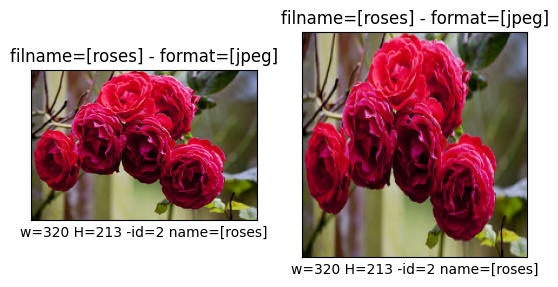

In [67]:
fig, ax = plt.subplots(nrows=1, ncols=2)
axi = ax[0]
axi.imshow(original_img/255, cmap=plt.cm.binary)
axi.set(
    title="filname=[{}] - format=[{}]".format(filename_1.numpy().decode('utf-8'), format_1.numpy().decode('utf-8')),
    xlabel="w={} H={} -id={} name=[{}]".format(width_1, height_1, class_id_1, class_name_1.numpy().decode("utf-8"))
)
axi.grid(False)
axi.set_xticks([])
axi.set_yticks([])

axi = ax[1]
axi.imshow(matrix_o/255, cmap=plt.cm.binary)
axi.set(
    title="filname=[{}] - format=[{}]".format(filename_1.numpy().decode('utf-8'), format_1.numpy().decode('utf-8')),
    xlabel="w={} H={} -id={} name=[{}]".format(width_1, height_1, class_id_1, class_name_1.numpy().decode("utf-8"))
)
axi.grid(False)
axi.set_xticks([])
axi.set_yticks([])
plt.show()

In [68]:
IMAGE_FEATURE_MAP = {
    'image/class_id': tf.io.FixedLenFeature([], tf.int64),
    'image/matrix': tf.io.FixedLenFeature([], tf.string),
}

In [69]:
def parse_one_sample(raw_example):
  x = tf.io.parse_single_example(raw_example, IMAGE_FEATURE_MAP)
  class_id_1 = x['image/class_id']
  matrix_1 = x['image/matrix']
  matrix_o = tf.io.parse_tensor(matrix_1, out_type=tf.float32)
  matrix_o = tf.ensure_shape(matrix_o, [192, 192, 3])
  class_id_1 = tf.ensure_shape(class_id_1, [])
  return matrix_o, class_id_1


def load_tfrecord_dataset(tfrecord_filename):
  raw_dataset = tf.data.TFRecordDataset(tfrecord_filename)
  print('total sample amount is', tfreord_counter(raw_dataset))
  return raw_dataset.map(lambda x: parse_one_sample(x))


ds = load_tfrecord_dataset(tfrecord_file)
print("spec: ", ds)

total sample amount is 3670
spec:  <_MapDataset element_spec=(TensorSpec(shape=(192, 192, 3), dtype=tf.float32, name=None), TensorSpec(shape=(), dtype=tf.int64, name=None))>


In [70]:
import os

file_to_delete = 'flower_record'

if os.path.exists(file_to_delete):
    os.remove(file_to_delete)
    print(f"'{file_to_delete}' has been deleted successfully.")
else:
    print(f"'{file_to_delete}' not found in the current directory.")

'flower_record' has been deleted successfully.
